In [1]:
import numpy as np
import pandas as pd
import os

from autopep8 import find_files
from mypy.join import combine_arg_names
from sklearn.inspection import permutation_importance

In [2]:
os.getcwd()

'C:\\Users\\jalat\\anaconda3\\major project'

In [3]:
### Load data obtained from arcgis pro

In [4]:
data = pd.read_csv(r"D:\Random Forest and XGB\Merged tables\Manipur.csv")
data

,OID_,LC_Type1,mode,fire,class,aspect,curvature,dewpoint,Dis_to_Bld,Dis_to_Rd,...,NDMI,rivers,NDVI,preci,RD,relhum,slope,Soil,tri,wind
0,0,0,1,1,1,9,0.002875,18.200219,5,4,...,0.142406,4,0.64850,0.099793,5,66.146119,1.337230,0.405216,0.484568,0.173087
1,1,0,1,1,1,7,0.000000,17.201471,2,4,...,0.102292,4,0.56090,0.080645,5,62.416774,11.564200,0.371972,0.532957,0.190204
2,2,0,1,1,1,9,0.085301,17.264422,3,5,...,0.096813,4,0.55060,0.081856,4,62.843899,7.552470,0.377584,0.424292,0.183729
3,3,0,1,1,1,8,-0.002875,18.285982,5,5,...,0.163788,4,0.70380,0.101235,5,66.666699,2.842780,0.410050,0.387387,0.164266
4,4,0,1,1,1,8,0.022364,18.336365,5,5,...,0.122249,4,0.59155,0.102135,5,66.969835,1.455210,0.412568,0.611111,0.158544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,595,17,0,0,0,9,0.000000,16.485775,5,5,...,0.243528,4,0.23520,0.062440,4,61.987935,0.036208,0.414131,0.111115,0.228978
590,596,17,0,0,0,1,0.000000,16.534997,5,3,...,0.224631,4,0.12400,0.063368,4,62.254647,0.000000,0.414971,-9999.000000,0.226411
591,597,17,0,0,0,1,0.000000,16.492086,4,3,...,0.259308,5,0.15730,0.063291,4,62.147572,0.000000,0.414839,-9999.000000,0.234242
592,598,17,0,0,0,1,0.000000,16.438913,5,4,...,0.253698,5,0.48070,0.063073,4,61.994216,0.000000,0.414577,-9999.000000,0.242775


In [5]:
x = data.drop(columns = ['OID_', 'LC_Type1','mode','fire','class'])
x

,aspect,curvature,dewpoint,Dis_to_Bld,Dis_to_Rd,elevation,FCR,Foresttype,lst,lulc,...,NDMI,rivers,NDVI,preci,RD,relhum,slope,Soil,tri,wind
0,9,0.002875,18.200219,5,4,70,1,2,29.10,2,...,0.142406,4,0.64850,0.099793,5,66.146119,1.337230,0.405216,0.484568,0.173087
1,7,0.000000,17.201471,2,4,673,1,2,28.59,2,...,0.102292,4,0.56090,0.080645,5,62.416774,11.564200,0.371972,0.532957,0.190204
2,9,0.085301,17.264422,3,5,449,1,2,29.61,2,...,0.096813,4,0.55060,0.081856,4,62.843899,7.552470,0.377584,0.424292,0.183729
3,8,-0.002875,18.285982,5,5,86,1,2,28.44,2,...,0.163788,4,0.70380,0.101235,5,66.666699,2.842780,0.410050,0.387387,0.164266
4,8,0.022364,18.336365,5,5,122,1,2,28.72,2,...,0.122249,4,0.59155,0.102135,5,66.969835,1.455210,0.412568,0.611111,0.158544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,9,0.000000,16.485775,5,5,768,0,6,23.61,17,...,0.243528,4,0.23520,0.062440,4,61.987935,0.036208,0.414131,0.111115,0.228978
590,1,0.000000,16.534997,5,3,768,0,6,23.41,17,...,0.224631,4,0.12400,0.063368,4,62.254647,0.000000,0.414971,-9999.000000,0.226411
591,1,0.000000,16.492086,4,3,768,0,6,23.03,17,...,0.259308,5,0.15730,0.063291,4,62.147572,0.000000,0.414839,-9999.000000,0.234242
592,1,0.000000,16.438913,5,4,768,0,6,23.18,17,...,0.253698,5,0.48070,0.063073,4,61.994216,0.000000,0.414577,-9999.000000,0.242775


In [6]:
y=data['class']
y

0      1
1      1
2      1
3      1
4      1
      ..
589    0
590    0
591    0
592    0
593    0
Name: class, Length: 594, dtype: int64

In [7]:
# Print column names in x
print("Column names in x:")
print(x.columns.tolist())

Column names in x:
['aspect', 'curvature', 'dewpoint', 'Dis_to_Bld', 'Dis_to_Rd', 'elevation', 'FCR', 'Foresttype', 'lst', 'lulc', 'mat', 'NDMI', 'rivers', 'NDVI', 'preci', 'RD', 'relhum', 'slope', 'Soil', 'tri', 'wind']


In [8]:
# Define all columns to scale (continuous and categorical)
all_cols = ['aspect', 'curvature', 'dewpoint', 'Dis_to_Bld', 'Dis_to_Rd', 'elevation', 'FCR', 'Foresttype', 'lst', 'lulc', 'mat', 'NDMI', 'rivers', 'NDVI', 'preci', 'RD', 'relhum', 'slope', 'Soil', 'tri', 'wind']
# Verify which columns exist
available_cols = [col for col in all_cols if col in x.columns]
print("\nAvailable columns:", available_cols)


Available columns: ['aspect', 'curvature', 'dewpoint', 'Dis_to_Bld', 'Dis_to_Rd', 'elevation', 'FCR', 'Foresttype', 'lst', 'lulc', 'mat', 'NDMI', 'rivers', 'NDVI', 'preci', 'RD', 'relhum', 'slope', 'Soil', 'tri', 'wind']


In [9]:
from sklearn.preprocessing import MinMaxScaler
# Apply Min-Max scaling to all columns
scaler = MinMaxScaler()
x[available_cols] = scaler.fit_transform(x[available_cols])

# Combine x and y
processed_data = x.copy()
processed_data['class'] = y

# Save processed data
processed_data.to_csv(r"D:\Random Forest and XGB\Random Forest\Manipur_processed_minmax.csv", index=False)
print("\nProcessed data saved to 'Manipur_processed_minmax.csv'")
print("Shape of processed data:", processed_data.shape)
print("First few rows of processed data:")
print(processed_data.head())
print("\nData range check (should be 0–1):")
print(processed_data.drop(columns=['class']).agg(['min', 'max']))


Processed data saved to 'Manipur_processed_minmax.csv'
Shape of processed data: (594, 22)
First few rows of processed data:
   aspect  curvature  dewpoint  Dis_to_Bld  Dis_to_Rd  elevation  FCR  \
0   1.000   0.614797  0.950273        1.00       0.75   0.005928  1.0   
1   0.750   0.607932  0.788793        0.25       0.75   0.280894  1.0   
2   1.000   0.811593  0.798971        0.50       1.00   0.178751  1.0   
3   0.875   0.601067  0.964140        1.00       1.00   0.013224  1.0   
4   0.875   0.661326  0.972286        1.00       1.00   0.029640  1.0   

   Foresttype       lst  lulc  ...  rivers      NDVI     preci   RD    relhum  \
0         0.0  0.655906   0.0  ...    0.75  0.769295  0.937934  1.0  0.816924   
1         0.0  0.615748   0.0  ...    0.75  0.672156  0.676832  1.0  0.648200   
2         0.0  0.696063   0.0  ...    0.75  0.660734  0.693353  0.5  0.667524   
3         0.0  0.603937   0.0  ...    0.75  0.830617  0.957598  1.0  0.840476   
4         0.0  0.625984   0.0  


High correlations (|r| > 0.8):
lulc vs FCR: 0.956
lulc vs Foresttype: 0.866
NDVI vs FCR: 0.847
NDVI vs lulc: 0.907
relhum vs preci: 0.906
wind vs dewpoint: 0.856


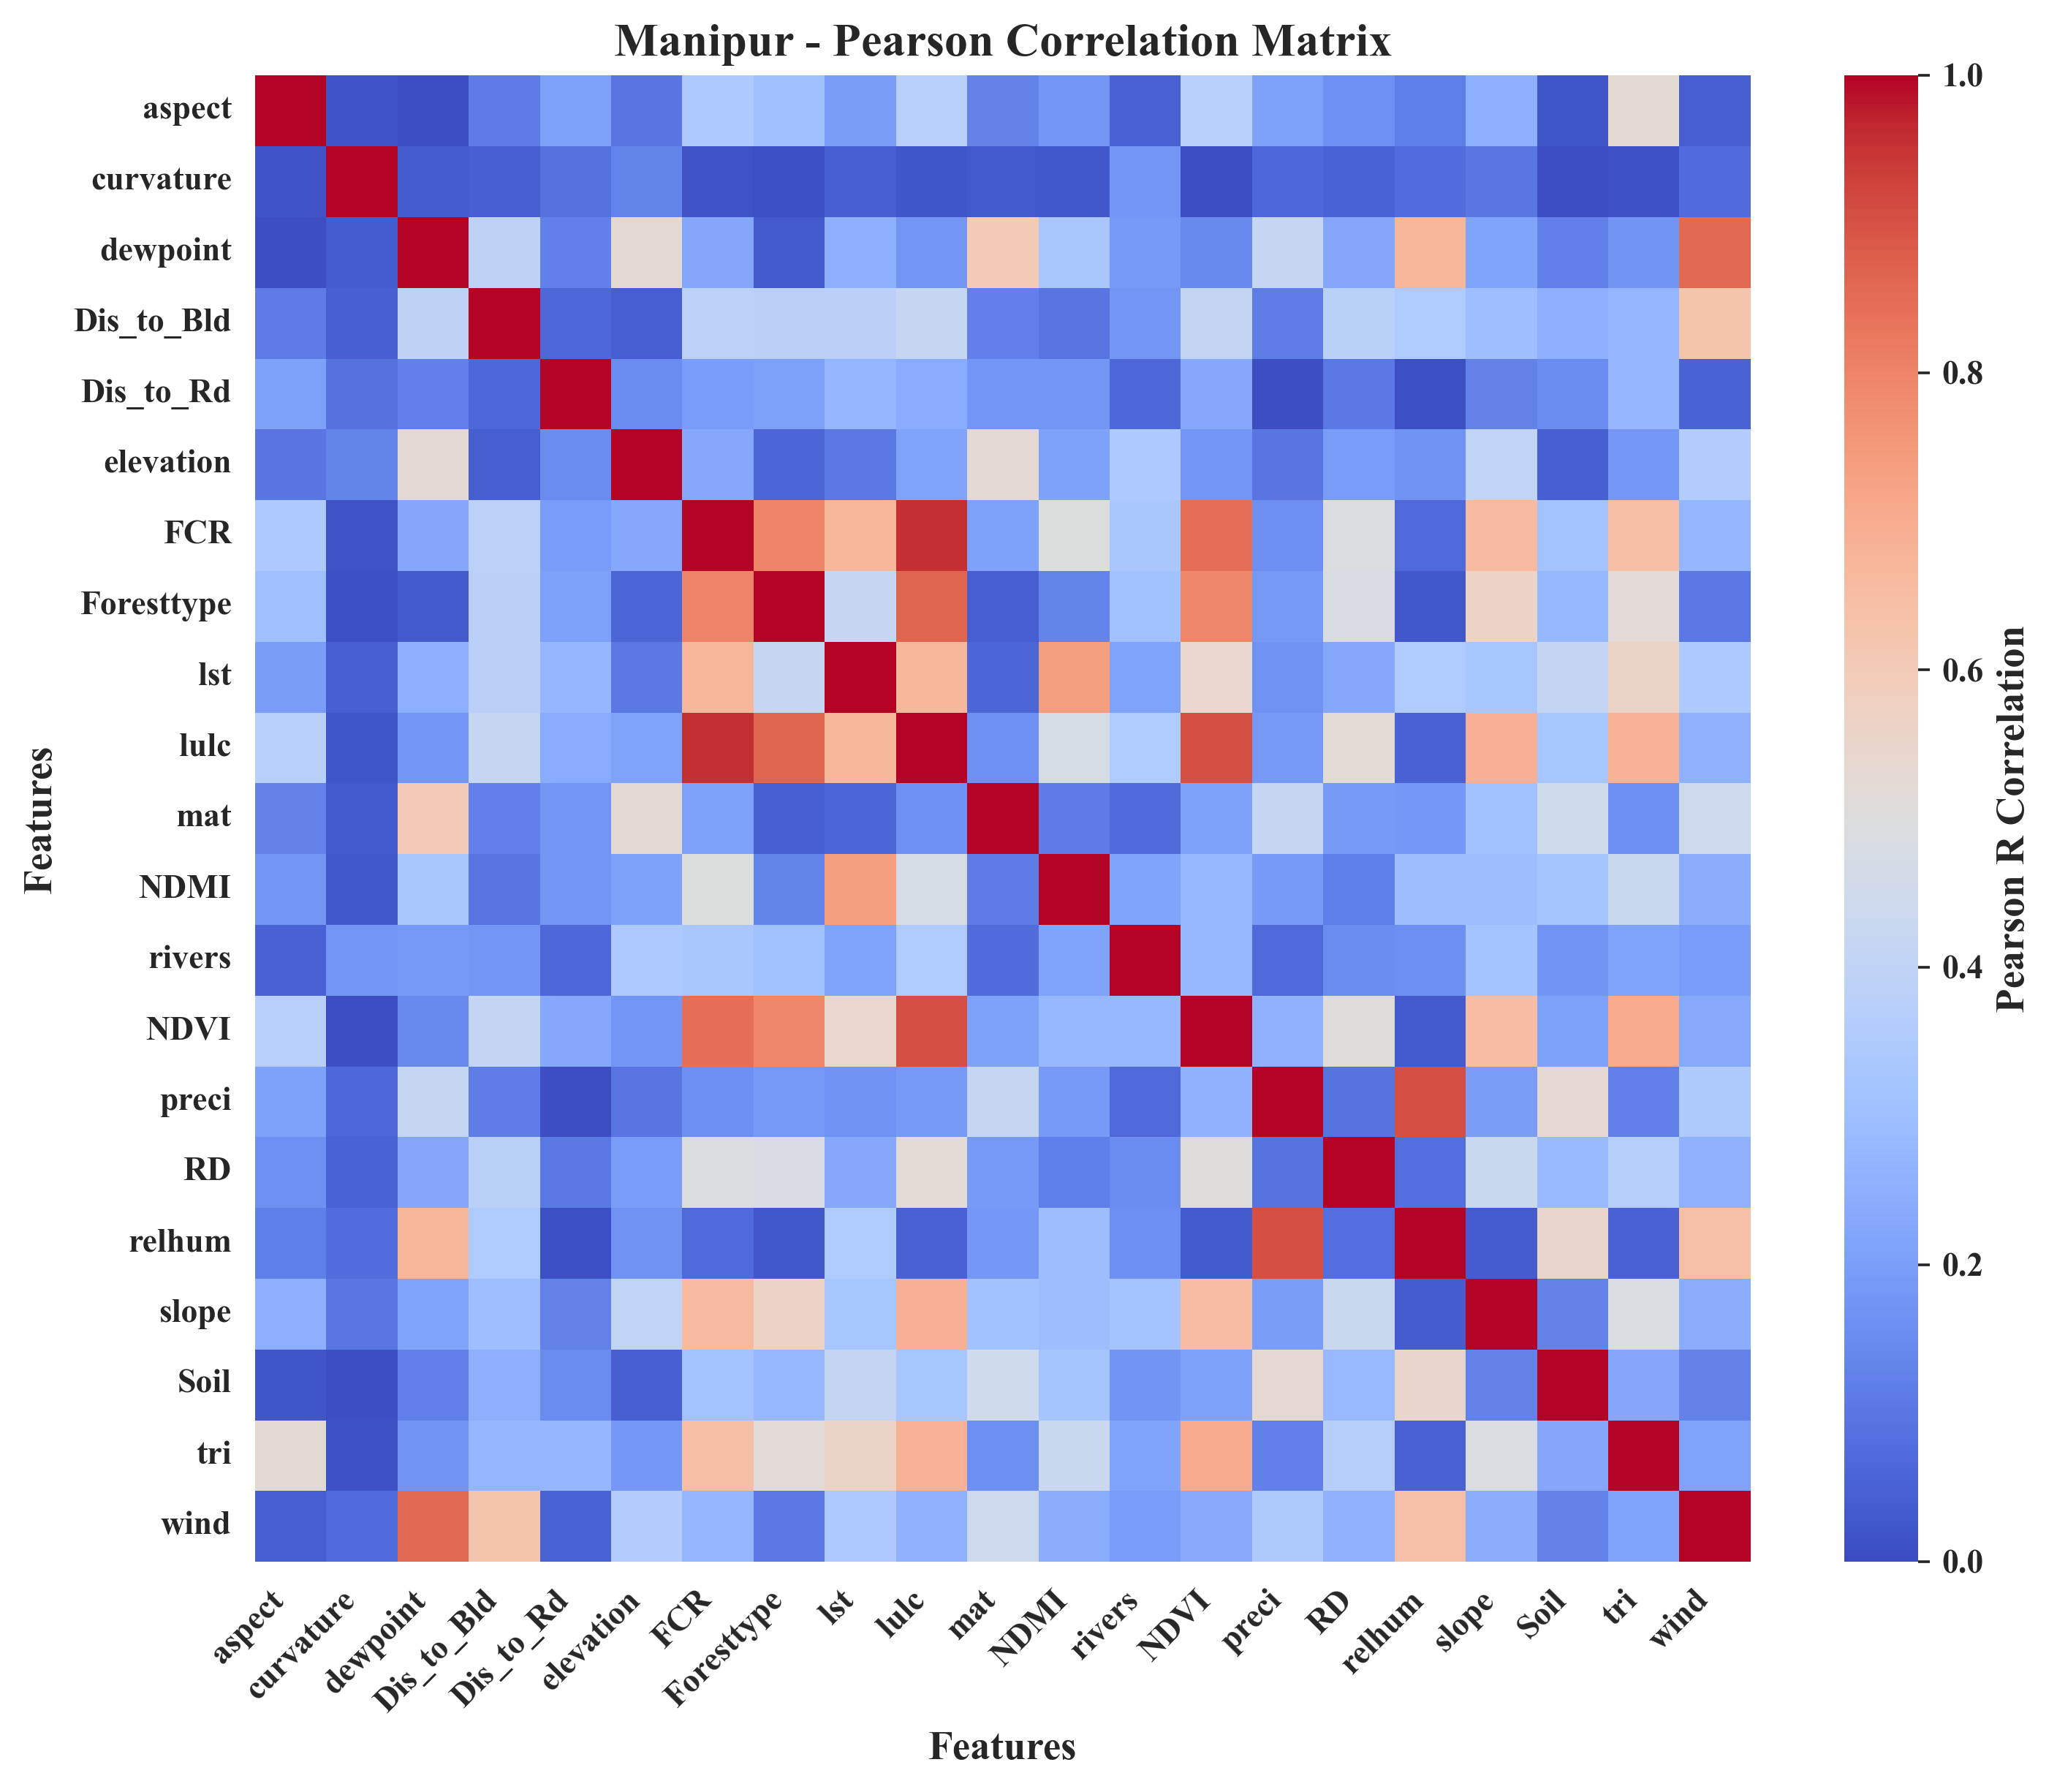


Data shape: (594, 22)

Column names: ['aspect', 'curvature', 'dewpoint', 'Dis_to_Bld', 'Dis_to_Rd', 'elevation', 'FCR', 'Foresttype', 'lst', 'lulc', 'mat', 'NDMI', 'rivers', 'NDVI', 'preci', 'RD', 'relhum', 'slope', 'Soil', 'tri', 'wind', 'class']

First 5 rows:
   aspect  curvature  dewpoint  Dis_to_Bld  Dis_to_Rd  elevation  FCR  \
0   1.000   0.614797  0.950273        1.00       0.75   0.005928  1.0   
1   0.750   0.607932  0.788793        0.25       0.75   0.280894  1.0   
2   1.000   0.811593  0.798971        0.50       1.00   0.178751  1.0   
3   0.875   0.601067  0.964140        1.00       1.00   0.013224  1.0   
4   0.875   0.661326  0.972286        1.00       1.00   0.029640  1.0   

   Foresttype       lst  lulc  ...  rivers      NDVI     preci   RD    relhum  \
0         0.0  0.655906   0.0  ...    0.75  0.769295  0.937934  1.0  0.816924   
1         0.0  0.615748   0.0  ...    0.75  0.672156  0.676832  1.0  0.648200   
2         0.0  0.696063   0.0  ...    0.75  0.660734  

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Load normalized data
data = pd.read_csv(r"D:\Random Forest and XGB\Random Forest\Manipur_processed_minmax.csv")
x = data.drop(columns=['class'])
y = data['class']

# Compute Pearson's correlation matrix
corr_matrix = x.corr(method='pearson').abs()

# Identify high correlations (|r| > 0.8)
print("\nHigh correlations (|r| > 0.8):")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col1, col2, corr_matrix.loc[col1, col2])
             for col1 in upper_tri.columns
             for col2 in upper_tri.index
             if upper_tri.loc[col2, col1] > 0.8]
for col1, col2, corr in high_corr:
    print(f"{col1} vs {col2}: {corr:.3f}")

# Set Times New Roman font
times_new_roman = fm.FontProperties(family='Times New Roman')

# Visualize correlation matrix
plt.figure(figsize=(10, 8), dpi=330)
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=0, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title("Manipur - Pearson Correlation Matrix", fontproperties=times_new_roman, fontsize=14, fontweight='bold')
plt.xlabel("Features", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.ylabel("Features", fontproperties=times_new_roman, fontsize=12, fontweight='bold')

# Customize tick labels
plt.xticks(rotation=45, ha='right', fontproperties=times_new_roman, fontsize=10, fontweight='bold')
plt.yticks(fontproperties=times_new_roman, fontsize=10, fontweight='bold')

# Customize colorbar label
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Pearson R Correlation', fontproperties=times_new_roman, fontsize=12, fontweight='bold')
cbar.tick_params(labelsize=10)
for label in cbar.get_yticklabels():
    label.set_fontproperties(times_new_roman)
    label.set_fontweight('bold')

# Save and show plot
plt.savefig(r"D:\Random Forest and XGB\Random Forest\Manipur_correlation_matrix.png", bbox_inches='tight')
plt.show()
plt.close()

# Preview data
print("\nData shape:", data.shape)
print("\nColumn names:", data.columns.tolist())
print("\nFirst 5 rows:")
print(data.head())

In [154]:
import pandas as pd

# Load normalized data
data = pd.read_csv(r"D:\Random Forest and XGB\Random Forest\Tripura_processed_minmax.csv")
x = data.drop(columns=['class'])
y = data['class']

# Drop specified features
cols_to_drop = ['FCR', 'Foresttype', 'dewpoint', 'relhum', 'wind']
x = x.drop(columns=[col for col in cols_to_drop if col in x.columns])

# Combine x and y
processed_data = x.copy()
processed_data['class'] = y

# Save final dataset
processed_data.to_csv(r"D:\Random Forest and XGB\Random Forest\Tripura_model.csv", index=False)

# Preview results
print("Final data shape:", processed_data.shape)
print("\nColumn names:", processed_data.columns.tolist())
print("\nFirst 5 rows:")
print(processed_data.head())
print("\nData range check (should be 0–1):")
print(processed_data.drop(columns=['class']).agg(['min', 'max']))

Final data shape: (453, 16)

Column names: ['aspect', 'curvature', 'Dis_to_Bld', 'Dis_to_Rd', 'elevation', 'lst', 'lulc', 'mat', 'NDMI', 'NDVI', 'preci', 'RD', 'slope', 'Soil', 'tri', 'class']

First 5 rows:
   aspect  curvature  Dis_to_Bld  Dis_to_Rd  elevation       lst      lulc  \
0   1.000   0.479217        0.50       0.75   0.235931  0.403454  0.000000   
1   1.000   0.469438        0.75       0.50   0.101732  0.855573  0.133333   
2   0.125   0.596577        1.00       0.75   0.183983  0.816327  0.000000   
3   0.750   0.528117        0.25       0.25   0.212121  0.577708  0.000000   
4   0.625   0.589242        0.25       0.50   0.281385  0.547881  0.000000   

        mat      NDMI      NDVI     preci        RD     slope      Soil  \
0  0.637829  0.658504  0.850577  0.659487  0.666667  0.020586  0.139717   
1  1.000000  0.188162  0.755221  0.048121  1.000000  0.079586  0.165105   
2  0.998057  0.428615  0.712833  0.044923  1.000000  0.078005  0.158940   
3  0.814592  0.661737  

In [155]:
data = pd.read_csv(r"D:\Random Forest and XGB\Random Forest\Tripura_model.csv")
data

x = data.drop(columns = ['class'])
x

y=data['class']
y
from sklearn.utils import shuffle

# Shuffle the rows of x and y
x,y = shuffle(x,y, random_state=0)

In [156]:
###Split Test and Train Data

In [157]:
from sklearn.model_selection import train_test_split

In [158]:
# Stratified split into train/test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0, stratify=y)

# Stratified split into train/validation
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=0, stratify=y_train)

#Print the shapes of the resulting sets
print("Training ste shape:", x_train.shape, y_train.shape)
print("Validation ste shape:", x_val.shape, y_val.shape)
print("Test ste shape:", x_test.shape, y_test.shape)

Training ste shape: (253, 15) (253,)
Validation ste shape: (64, 15) (64,)
Test ste shape: (136, 15) (136,)


In [159]:
###Use GridSearchCV to find best hyperparameters and Models and return the dataframe

In [160]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [161]:
# Your model parameters
model_params = {
    'random_forest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'n_estimators': [50],
            'max_depth': [2, 3],
            'min_samples_split': [20, 30],
            'min_samples_leaf': [8, 12]
        }
    },
    'xgboost': {
        'model': XGBClassifier(random_state=42, eval_metric='auc'),
        'params': {
            'learning_rate': [0.005, 0.01],
            'max_depth': [2],
            'subsample': [0.6],
            'colsample_bytree': [0.6],
            'min_child_weight': [5, 10],
            'reg_lambda': [10, 20]
        }
    }
}

In [162]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np

# Train and evaluate models
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1_macro', n_jobs=-1)
    clf.fit(x_train, y_train)

    # Validation metrics
    y_pred_val = clf.predict(x_val)
    cm_val = confusion_matrix(y_val, y_pred_val, labels=[0, 1])
    tn, fp, fn, tp = cm_val.ravel()
    auc_val = roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]) if len(np.unique(y_val)) > 1 else np.nan

    # Test metrics
    y_pred_test = clf.predict(x_test)
    cm_test = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
    auc_test = roc_auc_score(y_test, clf.predict_proba(x_test)[:, 1]) if len(np.unique(y_test)) > 1 else np.nan

    # Feature importances
    importances = clf.best_estimator_.feature_importances_
    importance_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    importance_df.to_csv(f"D:\\Random Forest and XGB\\Random Forest\\{model_name}_importances_Tripura.csv", index=False)

    scores.append({
        'model': model_name,
        'best_cv_score': clf.best_score_,
        'best_params': clf.best_params_,
        'accuracy_val': accuracy_score(y_val, y_pred_val),
        'precision_val': precision_score(y_val, y_pred_val, pos_label=1, zero_division=0),
        'recall_val': recall_score(y_val, y_pred_val, pos_label=1, zero_division=0),
        'f1_val': f1_score(y_val, y_pred_val, pos_label=1, zero_division=0),
        'auc_val': auc_val,
        'confusion_matrix_val': f1_score(y_val, y_pred_val, pos_label=1, zero_division=0),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'f1_test': f1_score(y_test, y_pred_test, pos_label=1, zero_division=0),
        'auc_test': auc_test,
        'confusion_matrix_test': cm_test.tolist(),
        'tn_val': tn, 'fp_val': fp, 'fn_val': fn, 'tp_val': tp,
        'tn_test': cm_test[0,0], 'fp_test': cm_test[0,1], 'fn_test': cm_test[1,0], 'tp_test': cm_test[1,1]
    })

    print(f"\n{model_name} Results:")
    print(f"Best CV Score (f1_macro): {clf.best_score_:.4f}")
    print(f"Best Parameters: {clf.best_params_}")
    print(f"Validation Confusion Matrix:\n{cm_val}\nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Validation AUC: {auc_val:.4f}")
    print(f"Test Confusion Matrix:\n{cm_test}")
    print(f"Test AUC: {auc_test:.4f}")
    print(f"Feature Importances (Top 5):\n{importance_df.head()}")


random_forest Results:
Best CV Score (f1_macro): 0.9868
Best Parameters: {'max_depth': 2, 'min_samples_leaf': 12, 'min_samples_split': 20, 'n_estimators': 50}
Validation Confusion Matrix:
[[23  0]
 [ 0 41]]
TN: 23, FP: 0, FN: 0, TP: 41
Validation AUC: 1.0000
Test Confusion Matrix:
[[49  0]
 [ 0 87]]
Test AUC: 1.0000
Feature Importances (Top 5):
       Feature  Importance
9         NDVI    0.267677
6         lulc    0.236974
13        Soil    0.118358
2   Dis_to_Bld    0.117174
10       preci    0.089162

xgboost Results:
Best CV Score (f1_macro): 0.9868
Best Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'reg_lambda': 10, 'subsample': 0.6}
Validation Confusion Matrix:
[[23  0]
 [ 0 41]]
TN: 23, FP: 0, FN: 0, TP: 41
Validation AUC: 1.0000
Test Confusion Matrix:
[[46  3]
 [ 0 87]]
Test AUC: 1.0000
Feature Importances (Top 5):
   Feature  Importance
12   slope    0.220348
9     NDVI    0.166863
6     lulc    0.160678
13    Soil    0.13

In [163]:
# Return DataFrame
scores_df = pd.DataFrame(scores)
scores_df.to_csv(r"D:\Random Forest and XGB\Random Forest\Tripura_model_scores.csv", index=False)
print("\nModel Scores DataFrame:")
print(scores_df)


Model Scores DataFrame:
           model  best_cv_score  \
0  random_forest       0.986846   
1        xgboost       0.986846   

                                         best_params  accuracy_val  \
0  {'max_depth': 2, 'min_samples_leaf': 12, 'min_...           1.0   
1  {'colsample_bytree': 0.6, 'learning_rate': 0.0...           1.0   

   precision_val  recall_val  f1_val  auc_val  confusion_matrix_val  \
0            1.0         1.0     1.0      1.0                   1.0   
1            1.0         1.0     1.0      1.0                   1.0   

   accuracy_test  ...  auc_test  confusion_matrix_test tn_val  fp_val  fn_val  \
0       1.000000  ...       1.0     [[49, 0], [0, 87]]     23       0       0   
1       0.977941  ...       1.0     [[46, 3], [0, 87]]     23       0       0   

   tp_val  tn_test  fp_test  fn_test  tp_test  
0      41       49        0        0       87  
1      41       46        3        0       87  

[2 rows x 21 columns]


In [164]:
###Classification report and the AUC_ROC curve

In [165]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

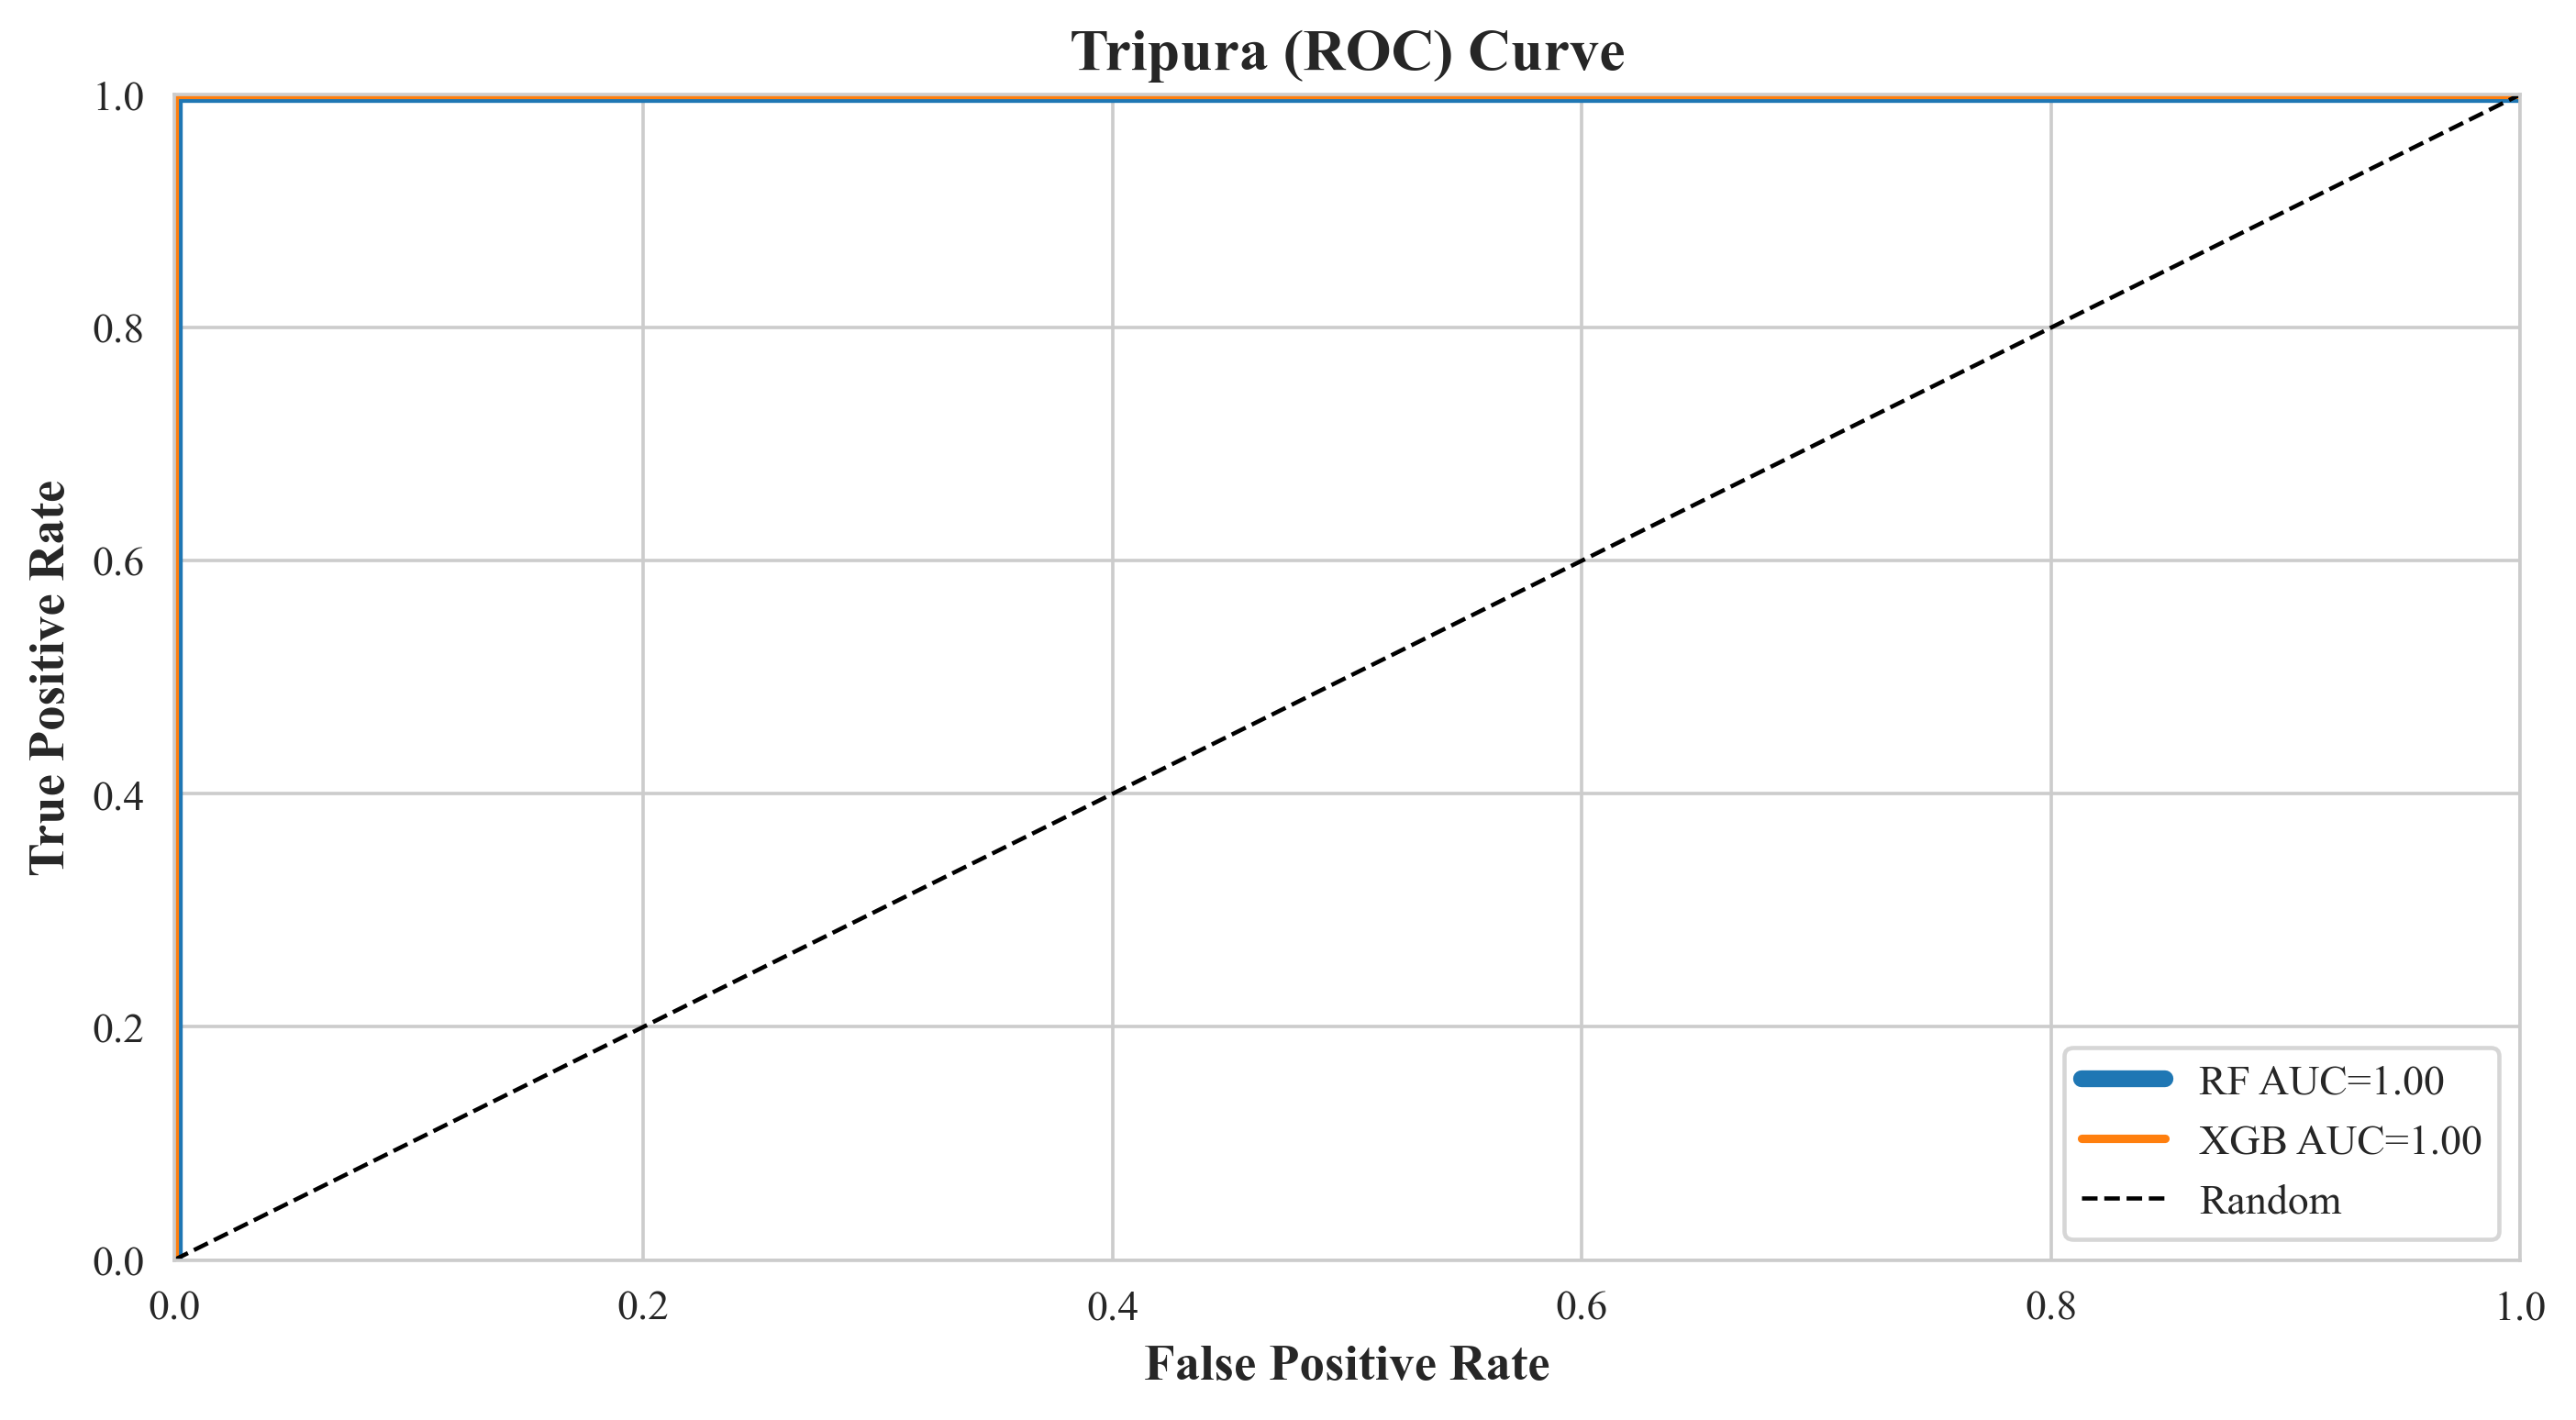

In [166]:
models = [
    ('RF', RandomForestClassifier(max_depth=2, min_samples_leaf=12, min_samples_split=20, n_estimators=50)),
    ('XGB', XGBClassifier(colsample_bytree=0.6, learning_rate=0.01, max_depth=2, min_child_weight=5, reg_lambda=10, subsample=0.6)),
]
report_data = []
auc_scores = {}

for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    report['model'] = name
    report_data.append(report)
    auc_scores[name] = roc_auc_score(y_test, y_prob)

report_df = pd.DataFrame(report_data).set_index('model')
report_df['auc_score'] = auc_scores.values()

# Set Times New Roman font
times_new_roman = fm.FontProperties(family='Times New Roman')

# Create ROC plot
fig, ax = plt.subplots(figsize=(10, 5), dpi=330)

# Plot ROC curves
for name, model in models:
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    linewidth = 4 if name == 'RF' else 2  # Thicker line for RF
    plt.plot(fpr, tpr, label=f'{name} AUC={auc_scores[name]:.2f}', linewidth=linewidth)

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

# Set plot limits and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.title('Tripura (ROC) Curve', fontproperties=times_new_roman, fontsize=14, fontweight='bold')

# Customize ticks and legend
plt.xticks(fontproperties=times_new_roman, fontsize=10)
plt.yticks(fontproperties=times_new_roman, fontsize=10)
plt.legend(loc='lower right', prop=times_new_roman, fontsize=10)

# Save and show plot
plt.savefig(r"D:\Random Forest and XGB\Random Forest\Tripura_ROC_AUC.png", bbox_inches='tight')
plt.show()
plt.close()

In [167]:
report_df

,0,1,accuracy,macro avg,weighted avg,auc_score
model,,,,,,
RF,"{'precision': 1.0, 'recall': 1.0, 'f1-score': ...","{'precision': 1.0, 'recall': 1.0, 'f1-score': ...",1.000000,"{'precision': 1.0, 'recall': 1.0, 'f1-score': ...","{'precision': 1.0, 'recall': 1.0, 'f1-score': ...",1.0
XGB,"{'precision': 1.0, 'recall': 0.938775510204081...","{'precision': 0.9666666666666667, 'recall': 1....",0.977941,"{'precision': 0.9833333333333334, 'recall': 0....","{'precision': 0.9786764705882353, 'recall': 0....",1.0


In [168]:
import pickle
#Fit and save each model
for name, model in models:
    model.fit(x_train, y_train)
    with open(f'{name}.pkl', 'wb') as file:
        pickle.dump(model, file)

#Load a saved model
with open(f'{name}.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

#Use the loaded model to predict
#Loaded_model.predict(x_test)

In [169]:
#Feature importances and permutation importances extraction of all algorithms

In [170]:
#Random Forest

In [171]:
RF = RandomForestClassifier(max_depth=2, min_samples_leaf=12, min_samples_split=20, n_estimators=50)
RF.fit(x_train, y_train)
RF.score(x_test, y_test)
y_pred = RF.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.3f}".format(acc))

Accuracy: 1.000


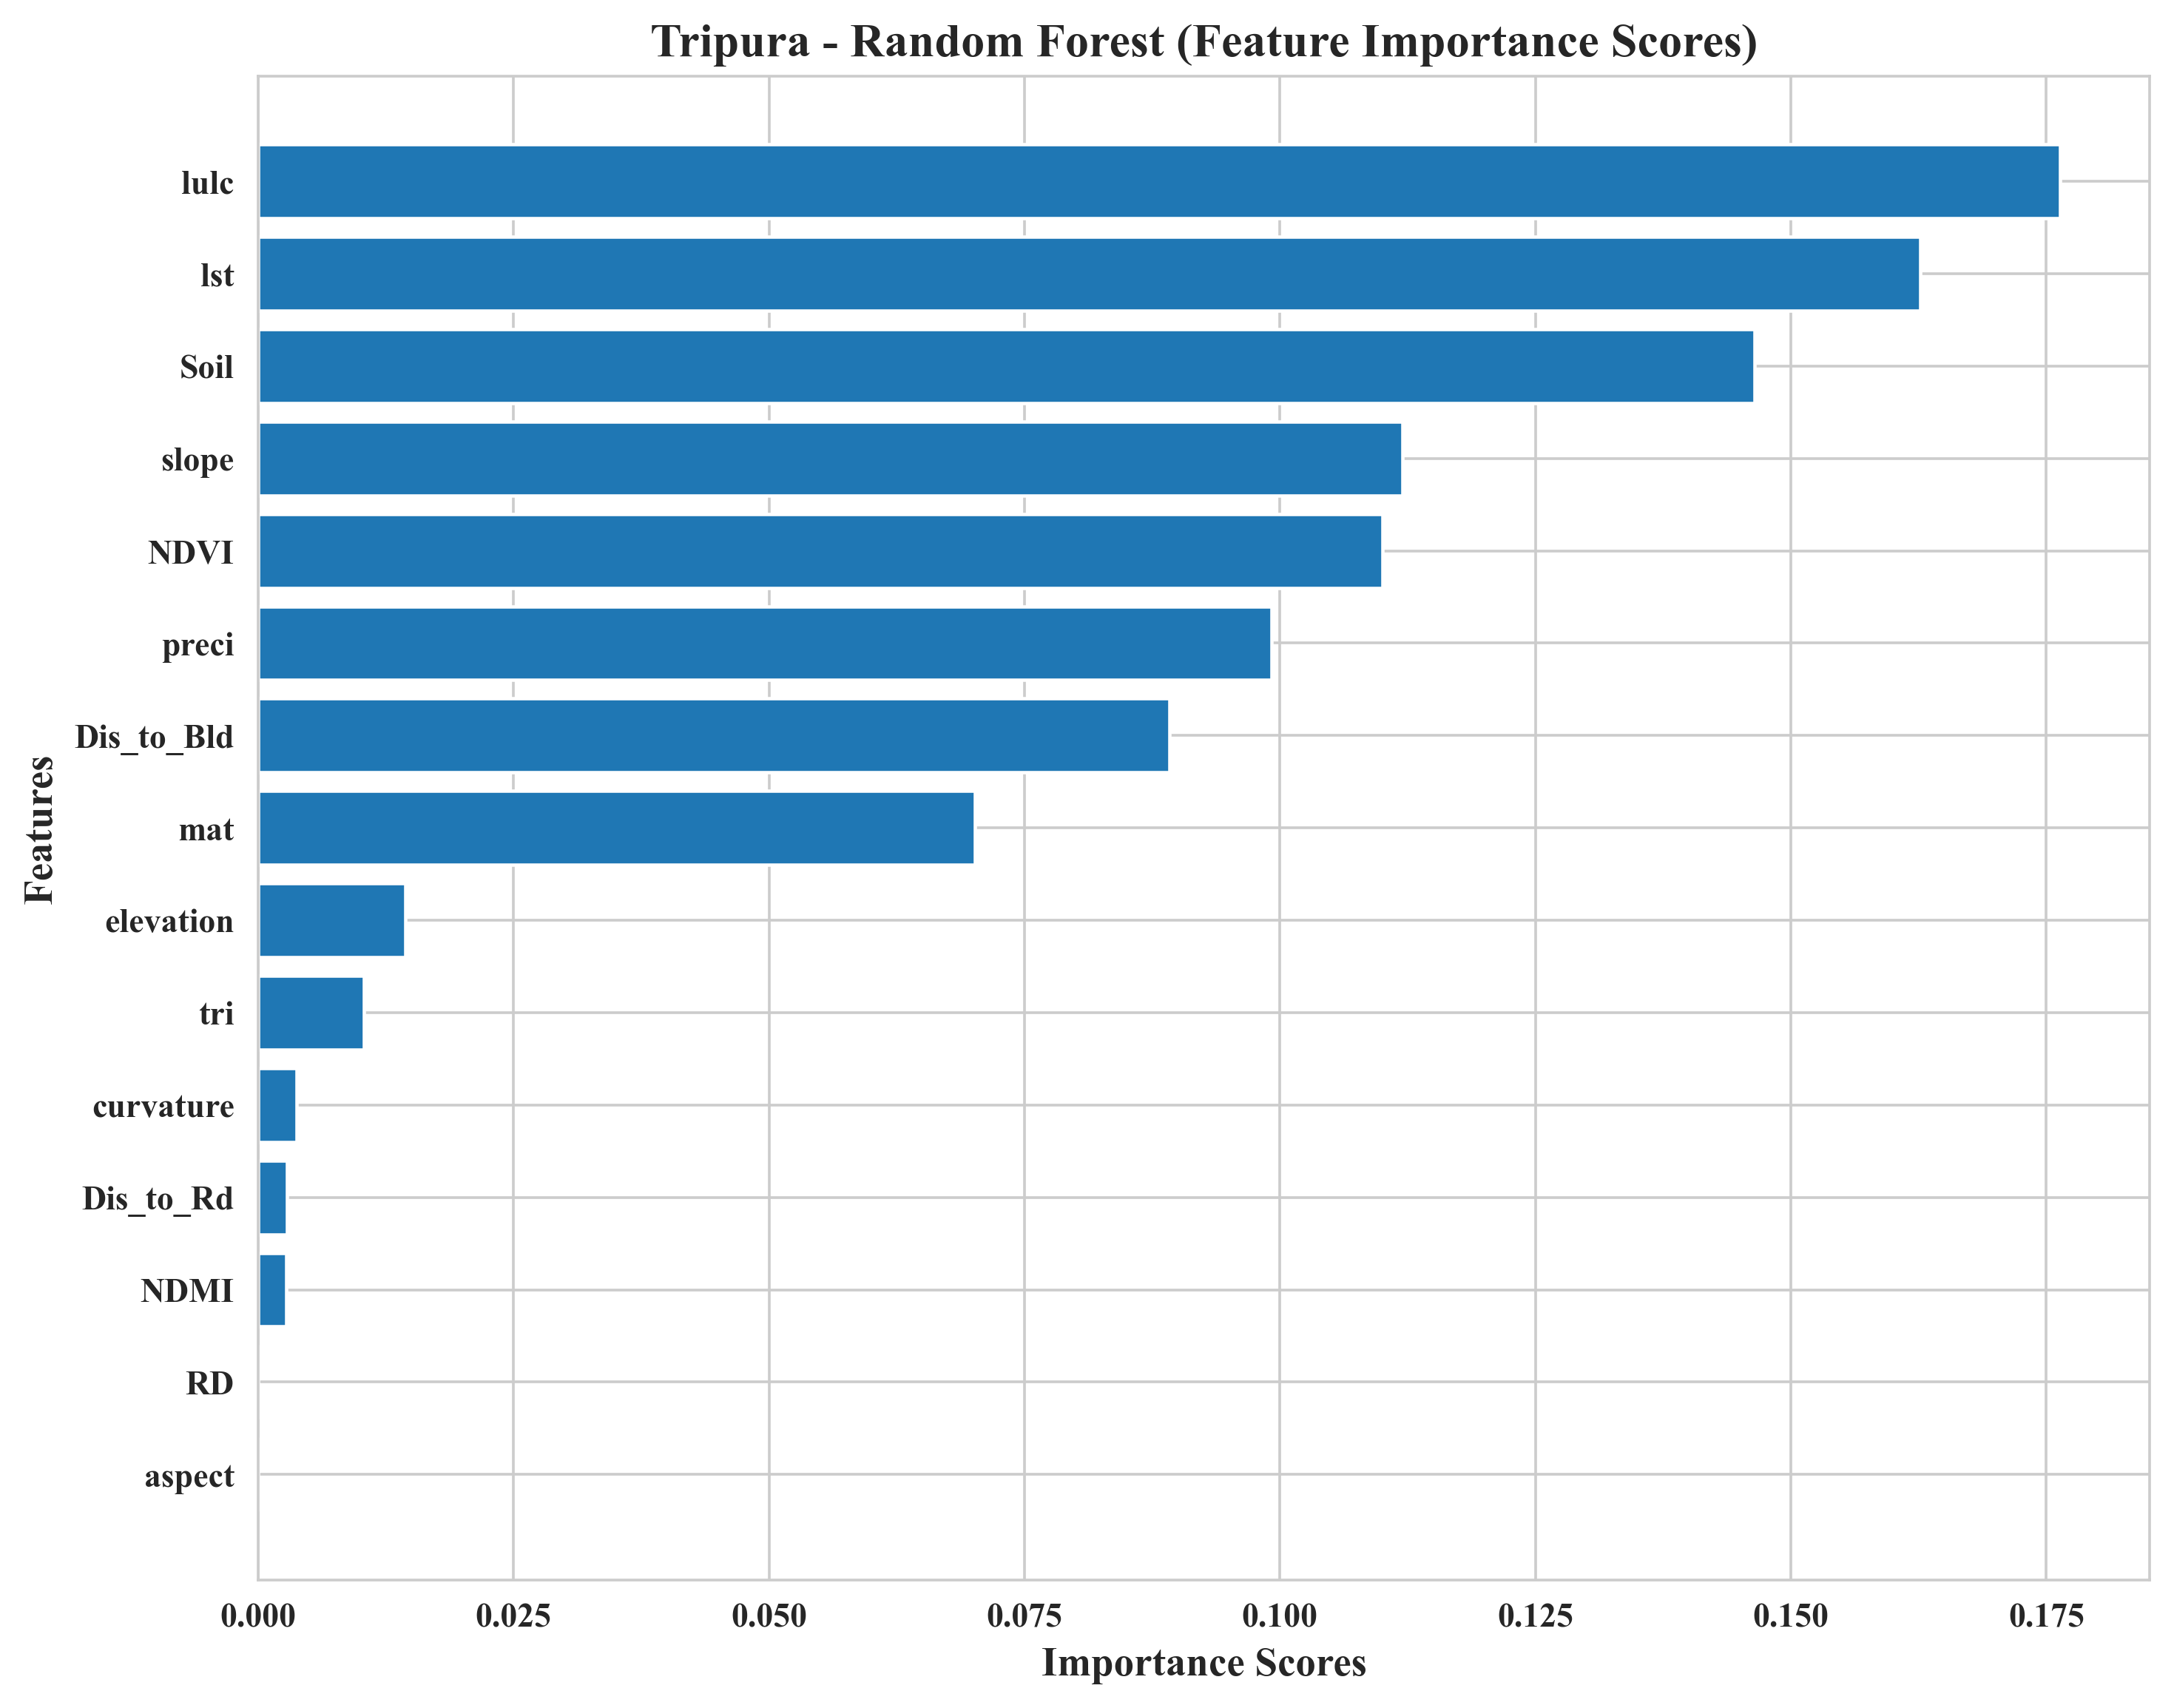

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Sort feature importances
sort = RF.feature_importances_.argsort()

# Set Times New Roman font
times_new_roman = fm.FontProperties(family='Times New Roman')

# Create horizontal bar plot
plt.figure(figsize=(10, 8), dpi=330)
plt.barh(x.columns[sort], RF.feature_importances_[sort])

# Set labels and title
plt.xlabel("Importance Scores", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.ylabel("Features", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.title("Tripura - Random Forest (Feature Importance Scores)", fontproperties=times_new_roman, fontsize=14, fontweight='bold')

# Customize tick labels
plt.xticks(fontproperties=times_new_roman, fontsize=10, fontweight='bold')
plt.yticks(fontproperties=times_new_roman, fontsize=10, fontweight='bold')

# Save and show plot
plt.savefig(r"D:\Random Forest and XGB\Random Forest\Tripura_FeatureImportance.png", bbox_inches='tight')
plt.show()
plt.close()

In [173]:
#Get feature importances and sort them
importances = RF.feature_importances_
sort = importances.argsort()

#Create a dataframe of feature names and importances
rf = pd.DataFrame({'Feature':x.columns[sort], 'Importance':importances[sort]})
rf_imp = rf.sort_values("Importance", ascending=False)
rf_imp

,Feature,Importance
14,lulc,0.176315
13,lst,0.162635
12,Soil,0.146458
11,slope,0.111954
10,NDVI,0.110038
9,preci,0.099205
8,Dis_to_Bld,0.089203
7,mat,0.070140
6,elevation,0.014381
5,tri,0.010348


In [174]:
#Permutation Importances

Text(0.5, 25.52222222222222, 'Permutation Importance')

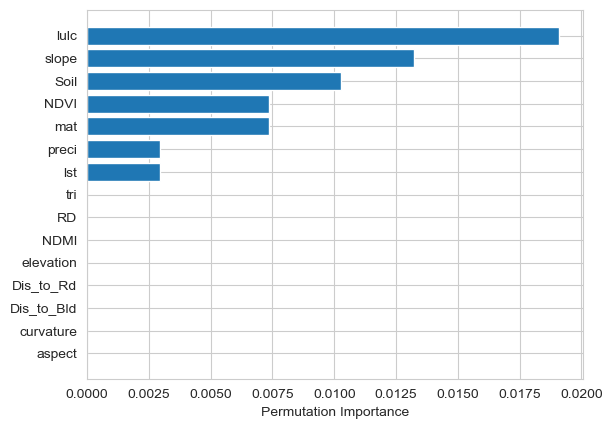

In [175]:
from sklearn.inspection import permutation_importance
perm_importance_RF = permutation_importance(RF, x_test, y_test)
sorted_idx = perm_importance_RF.importances_mean.argsort()
importances = perm_importance_RF.importances_mean.copy()
importances[importances < 0] = 0
plt.barh(x.columns[sorted_idx], importances[sorted_idx])
plt.savefig(r"D:\Random Forest and XGB\Random Forest\Tripura_PermutationImportance.png")
plt.xlabel("Permutation Importance")

In [176]:
#Extreme Gradient Boosting (XGB)

In [177]:
XGB = XGBClassifier(colsample_bytree=0.6, learning_rate=0.01, max_depth=2, min_child_weight=5, reg_lambda=10, subsample=0.6)
XGB.fit(x_train, y_train)
XGB.score(x_test, y_test)
y_pred = XGB.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.3f}".format(acc))

Accuracy: 0.978


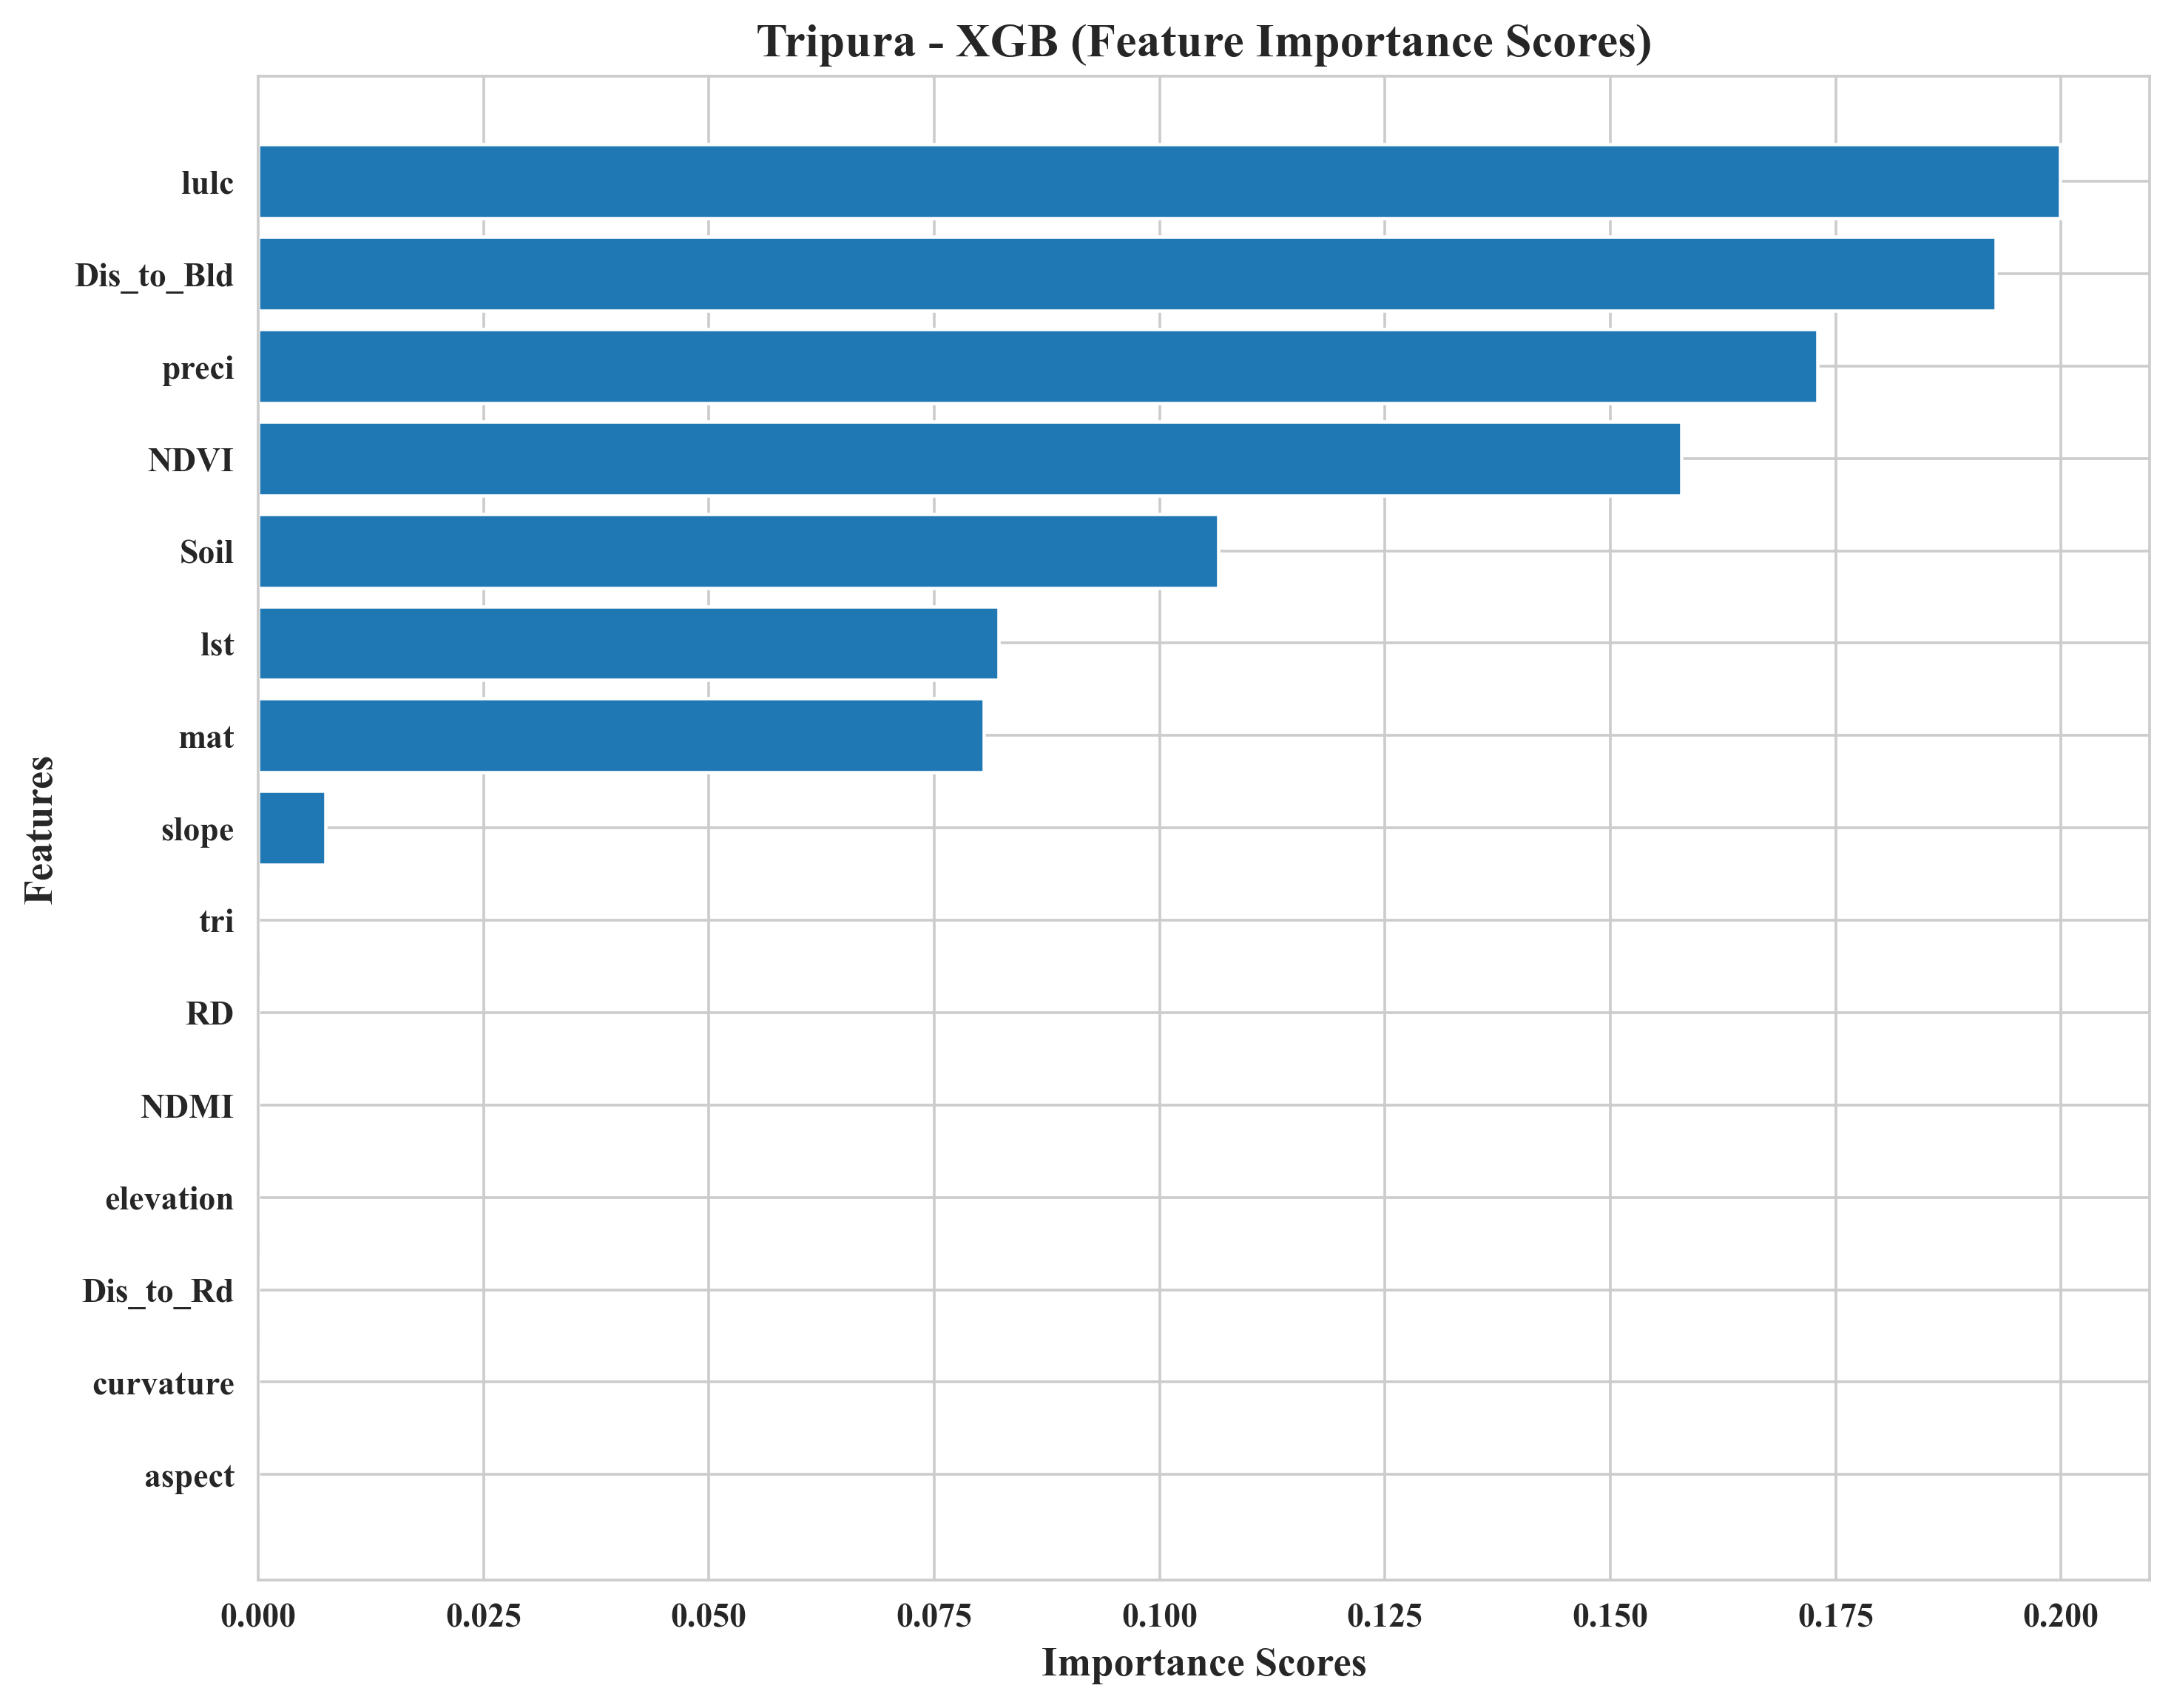

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Sort feature importances
sort = XGB.feature_importances_.argsort()

# Set Times New Roman font
times_new_roman = fm.FontProperties(family='Times New Roman')

# Create horizontal bar plot
plt.figure(figsize=(10, 8), dpi=330)
plt.barh(x.columns[sort], XGB.feature_importances_[sort])

# Set labels and title
plt.xlabel("Importance Scores", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.ylabel("Features", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
plt.title("Tripura - XGB (Feature Importance Scores)", fontproperties=times_new_roman, fontsize=14, fontweight='bold')

# Customize tick labels
plt.xticks(fontproperties=times_new_roman, fontsize=10, fontweight='bold')
plt.yticks(fontproperties=times_new_roman, fontsize=10, fontweight='bold')

# Save and show plot
plt.savefig(r"D:\Random Forest and XGB\XGB\Tripura_FeatureImportance.png", bbox_inches='tight')
plt.show()
plt.close()

In [179]:
#Get feature importances and sort them
XGB_importances = XGB.feature_importances_
sort = XGB_importances.argsort()

#Create a dataframe of feature names and importances
xgb = pd.DataFrame({'Feature':x.columns[sort], 'Importance':XGB_importances[sort]})
xgb_imp = xgb.sort_values("Importance", ascending=False)
xgb_imp

,Feature,Importance
14,lulc,0.199862
13,Dis_to_Bld,0.192732
12,preci,0.172970
11,NDVI,0.157851
10,Soil,0.106497
9,lst,0.082153
8,mat,0.080479
7,slope,0.007456
0,aspect,0.000000
1,curvature,0.000000


In [180]:
#Merging the data frame

In [181]:
import pandas as pd
import numpy as np

# Assuming rf_imp, xgb_imp, x are defined
# rf_imp, xgb_imp: DataFrames with Feature, Importance; x: data.drop(columns=['class'])

model_names = ['RF', 'XGB']

# Initialize combined DataFrame with features as index
combined_df = pd.DataFrame(index=x.columns, columns=model_names)

# Populate combined DataFrame
for model_name, df in zip(model_names, [rf_imp, xgb_imp]):
    for _, row in df.iterrows():
        combined_df.loc[row['Feature'], model_name] = row['Importance']

# Convert to float and fill NaNs with 0
combined_df = combined_df.astype(float).fillna(0)

# Debug: Check for NaNs and sums
print("\nCombined DataFrame before normalization (NaNs filled with 0):")
print(combined_df)
print("\nSums before normalization:")
print(combined_df.sum())

# Normalize and round to integers (sum to 100)
for model in model_names:
    if combined_df[model].sum() > 0:
        # Normalize to sum to 100 (float)
        weights = (combined_df[model] / combined_df[model].sum()) * 100
        # Round to integers
        weights_rounded = np.floor(weights).astype(int)
        # Distribute remainder to ensure sum = 100
        remainder = 100 - weights_rounded.sum()
        if remainder > 0:
            # Add 1 to features with largest decimal parts
            decimal_parts = weights - weights_rounded
            top_indices = decimal_parts.nlargest(remainder).index
            for idx in top_indices:
                weights_rounded.loc[idx] += 1
        combined_df[model] = weights_rounded
    else:
        combined_df[model] = 0  # Fallback for zero sum

# Debug: Verify sums
print("\nCombined Feature Importances (Integer Weights for ArcMap):")
print(combined_df)
print("\nSum of weights after normalization:")
print(combined_df.sum())

# Save to CSV for ArcMap
combined_df.to_csv(r"D:\Random Forest and XGB\XGB\MA_combined_feature_importances.csv")


Combined DataFrame before normalization (NaNs filled with 0):
                  RF       XGB
aspect      0.000000  0.000000
curvature   0.003764  0.000000
Dis_to_Bld  0.089203  0.192732
Dis_to_Rd   0.002825  0.000000
elevation   0.014381  0.000000
lst         0.162635  0.082153
lulc        0.176315  0.199862
mat         0.070140  0.080479
NDMI        0.002736  0.000000
NDVI        0.110038  0.157851
preci       0.099205  0.172970
RD          0.000000  0.000000
slope       0.111954  0.007456
Soil        0.146458  0.106497
tri         0.010348  0.000000

Sums before normalization:
RF     1.0
XGB    1.0
dtype: float64

Combined Feature Importances (Integer Weights for ArcMap):
            RF  XGB
aspect       0    0
curvature    0    0
Dis_to_Bld   9   19
Dis_to_Rd    0    0
elevation    2    0
lst         16    8
lulc        18   20
mat          7    8
NDMI         0    0
NDVI        11   16
preci       10   17
RD           0    0
slope       11    1
Soil        15   11
tri          1  

C:\Users\jalat\AppData\Local\Temp\ipykernel_32920\1959004552.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontproperties=times_new_roman, fontsize=10, fontweight='bold')


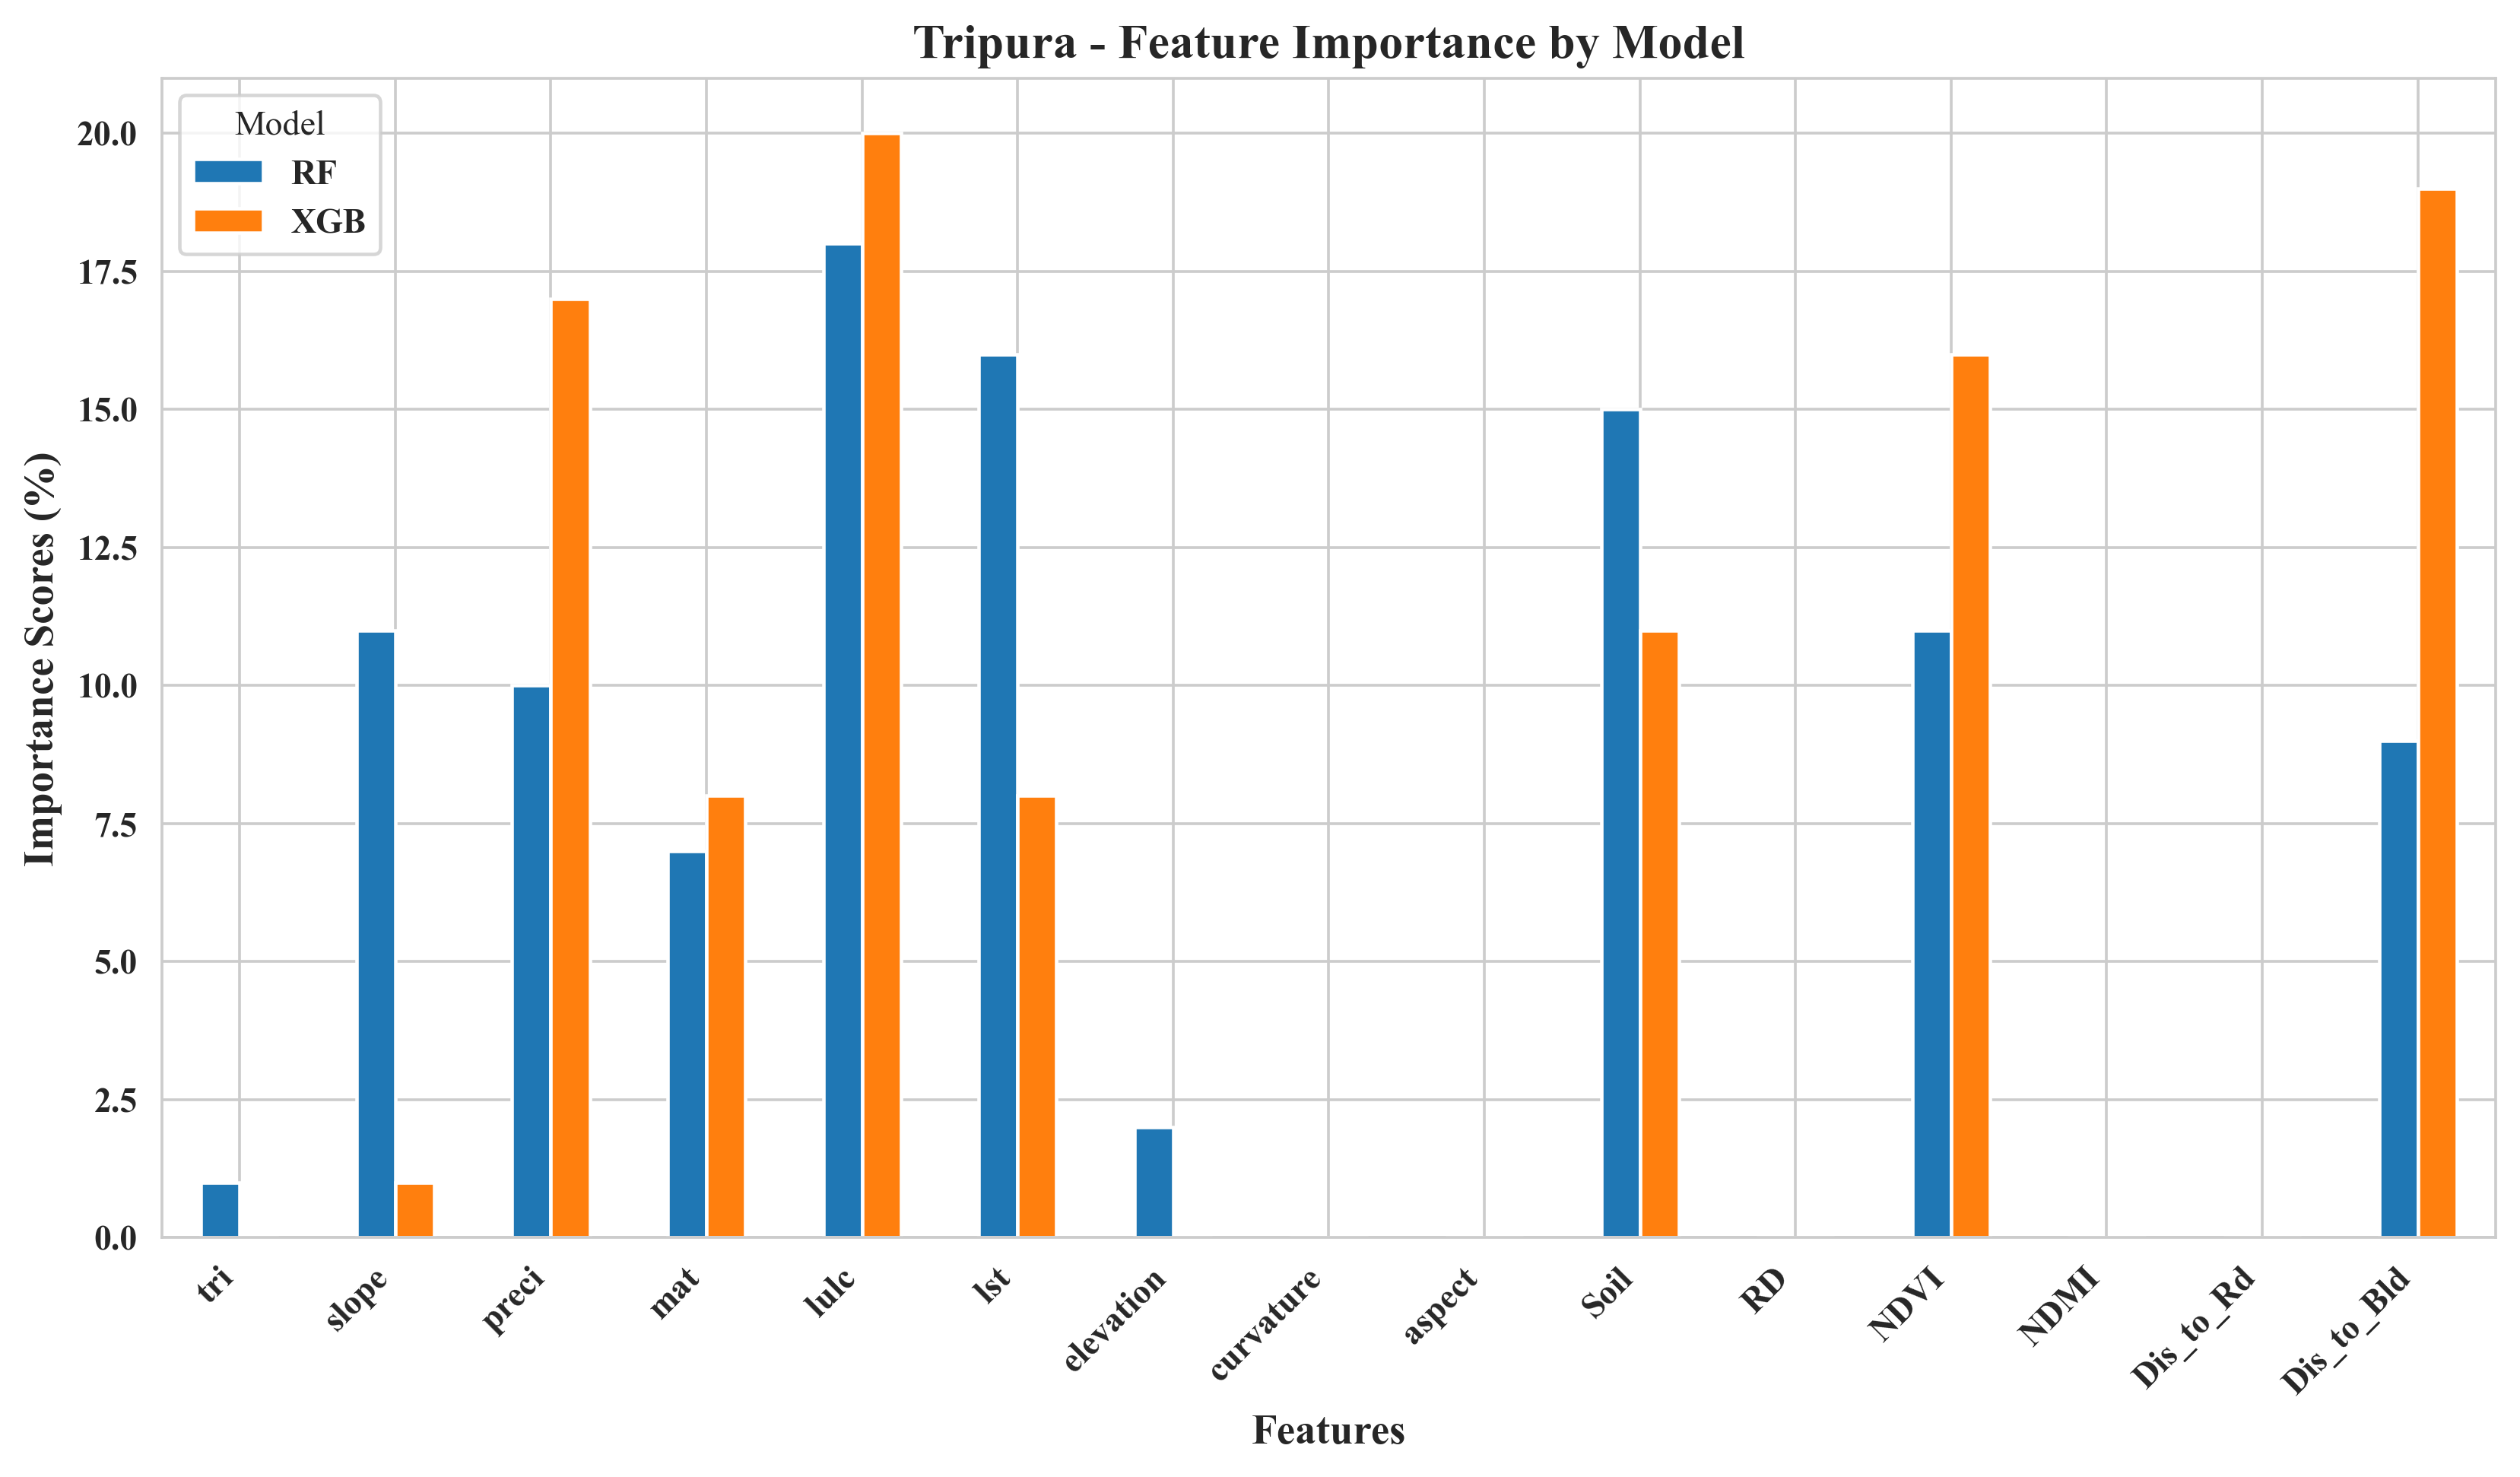

In [182]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Assuming combined_df is defined (from combined_feature_importances_step18.py)
# combined_df: 21 features x [RF, XGB], integer weights summing to 100

# Set Times New Roman font
times_new_roman = fm.FontProperties(family='Times New Roman')

# Create bar plot of feature importance sorted by feature name
fig, ax = plt.subplots(figsize=(12, 6), dpi=330)
combined_df.sort_index(ascending=False, inplace=True)
combined_df.plot(kind='bar', ax=ax)

# Set labels and title
ax.set_xlabel("Features", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
ax.set_ylabel("Importance Scores (%)", fontproperties=times_new_roman, fontsize=12, fontweight='bold')
ax.set_title("Tripura - Feature Importance by Model", fontproperties=times_new_roman, fontsize=14, fontweight='bold')

# Customize tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontproperties=times_new_roman, fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=times_new_roman, fontsize=10, fontweight='bold')

# Customize legend
ax.legend(title='Model', title_fontproperties=times_new_roman, prop={'family': 'Times New Roman', 'size': 10, 'weight': 'bold'}, fontsize=10)

# Save and show plot
plt.savefig(r"D:\Random Forest and XGB\XGB\Tripura_Combined_FeatureImportance.png", bbox_inches='tight')
plt.show()
plt.close()